In [10]:
library(ggplot2)
library(dplyr)
# Load the required libraries
library(ggpubr)

In [11]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/sRNA_STAR_testing")

In [12]:
data <- read.csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/data/sRNA_all_genome_type_mapping.csv", header=TRUE,sep=';')
data
# Round the values in the Measure_Values column to two decimal places
data$Measure.Values <- round(data$Measure.Values, 2)
# Remove rows with NA values using na.omit
data <- na.omit(data)
# Define the desired order of Strains
desired_strains_order <- c('C57BL_6NJ', 'BALB_cJ', 'A_J', 'FVB_NJ', 'C3H_HeJ', 'LP_J', '129S1_SvImJ', 'DBA_2J', 'AKR_J', 'CBA_J', 'NZO_HlLtJ', 'NOD_ShiLtJ', 'WSB_EiJ', 'CAST_EiJ', 'PWK_PhJ', 'SPRET_EiJ')

# Define the desired order of Measure_Names based on unique, unique loci, and multi loci
desired_measure_order <- c( "Reads Mapped To Too Many Loci","Reads Mapped To Multiple Loci", "Uniquely mapped reads" )  # Replace with your order

# Define the desired order for Timepoint
desired_timepoint_order <- c("E16.5", "P12.5", "P20.5")


desired_genome_order <- c( "GRCm38","GRCm39", "illumina" ,"Pac-Bio") 


Timepoint,Strains,genomes,Replicates,Measure.Names,Measure.Values
<chr>,<chr>,<chr>,<int>,<chr>,<dbl>
E16.5,129S1_SvImJ,GRCm38,3,Uniquely mapped reads,42.15
E16.5,129S1_SvImJ,GRCm38,2,Uniquely mapped reads,42.25
E16.5,129S1_SvImJ,GRCm38,1,Uniquely mapped reads,43.67
E16.5,129S1_SvImJ,GRCm38,3,Reads Mapped To Multiple Loci,29.81
E16.5,129S1_SvImJ,GRCm38,2,Reads Mapped To Multiple Loci,31.47
E16.5,129S1_SvImJ,GRCm38,1,Reads Mapped To Multiple Loci,29.39
E16.5,129S1_SvImJ,GRCm38,3,Reads Mapped To Too Many Loci,3.53
E16.5,129S1_SvImJ,GRCm38,2,Reads Mapped To Too Many Loci,3.37
E16.5,129S1_SvImJ,GRCm38,1,Reads Mapped To Too Many Loci,3.61


In [13]:
# Create a custom factor with the desired order for Timepoint
data$Timepoint <- factor(data$Timepoint, levels = desired_timepoint_order)

# Create a custom factor with the desired order for Measure_Names
data$Measure.Names <- factor(data$Measure.Names, levels = desired_measure_order)


data$genomes <- factor(data$genomes, levels = desired_genome_order)
# Create a custom factor with the desired order for Strains
data$Strains <- factor(data$Strains, levels = desired_strains_order)

# Define custom colors for stacked bars and error bars
stacked_bar_colors <- c( "#1f77b4","#2ca02c","#ff7f0e", "#d62728" )  # Replace with your colors
error_bar_color <- "#000000"   # Replace with your color




In [14]:
filter(data, Measure.Names == "Uniquely mapped reads")

Timepoint,Strains,genomes,Replicates,Measure.Names,Measure.Values
<fct>,<fct>,<fct>,<int>,<fct>,<dbl>
E16.5,129S1_SvImJ,GRCm38,3,Uniquely mapped reads,42.15
E16.5,129S1_SvImJ,GRCm38,2,Uniquely mapped reads,42.25
E16.5,129S1_SvImJ,GRCm38,1,Uniquely mapped reads,43.67
E16.5,129S1_SvImJ,GRCm39,3,Uniquely mapped reads,28.84
E16.5,129S1_SvImJ,GRCm39,2,Uniquely mapped reads,28.93
E16.5,129S1_SvImJ,GRCm39,1,Uniquely mapped reads,30.22
E16.5,129S1_SvImJ,illumina,3,Uniquely mapped reads,46.16
E16.5,129S1_SvImJ,illumina,2,Uniquely mapped reads,47.23
E16.5,129S1_SvImJ,illumina,1,Uniquely mapped reads,47.74


In [15]:
filter(data, Timepoint == "E16.5")

Timepoint,Strains,genomes,Replicates,Measure.Names,Measure.Values
<fct>,<fct>,<fct>,<int>,<fct>,<dbl>
E16.5,129S1_SvImJ,GRCm38,3,Uniquely mapped reads,42.15
E16.5,129S1_SvImJ,GRCm38,2,Uniquely mapped reads,42.25
E16.5,129S1_SvImJ,GRCm38,1,Uniquely mapped reads,43.67
E16.5,129S1_SvImJ,GRCm38,3,Reads Mapped To Multiple Loci,29.81
E16.5,129S1_SvImJ,GRCm38,2,Reads Mapped To Multiple Loci,31.47
E16.5,129S1_SvImJ,GRCm38,1,Reads Mapped To Multiple Loci,29.39
E16.5,129S1_SvImJ,GRCm38,3,Reads Mapped To Too Many Loci,3.53
E16.5,129S1_SvImJ,GRCm38,2,Reads Mapped To Too Many Loci,3.37
E16.5,129S1_SvImJ,GRCm38,1,Reads Mapped To Too Many Loci,3.61


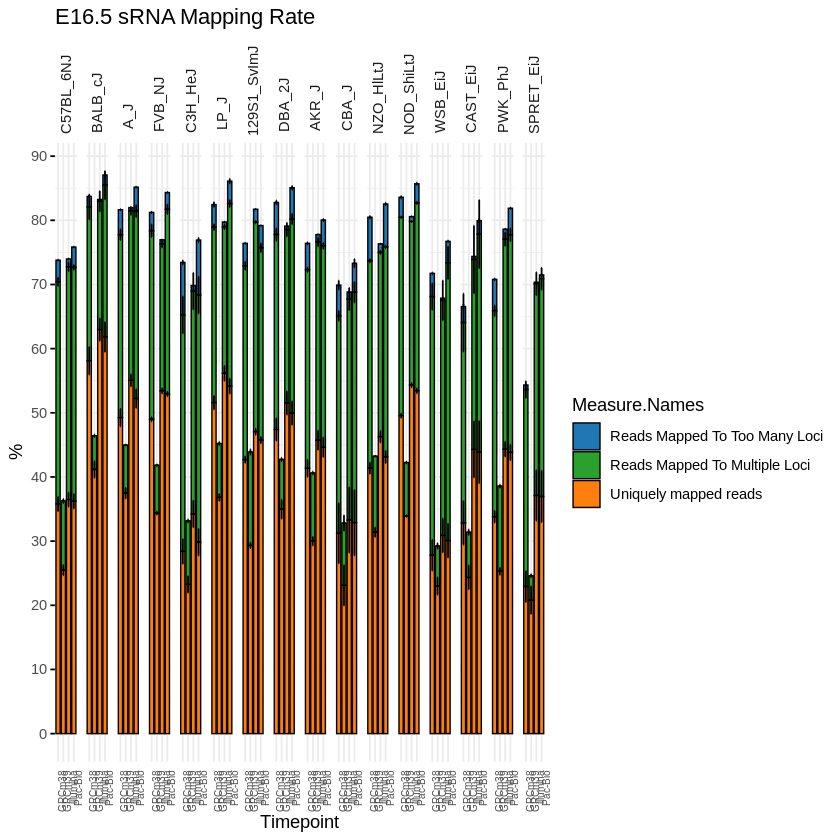

In [16]:
# Your existing code for reading and preprocessing data here...
# Create the stacked bar plot with error bars using ggbarplot
plot <- ggbarplot(filter(data, Timepoint == 'E16.5'),
          x = "genomes", y = "Measure.Values", 
          fill= "Measure.Names",
          add = "mean_se",
          width =0.8,
          add.params = list(color = "#000000"),
          nrow =1,
          size= 0.4,
          facet.by = "Strains",
          error.plot = "errorbar",
          title = "E16.5 sRNA Mapping Rate") + 
   # Apply ggpubr theme for consistency  # Major breaks every 10
  geom_hline(yintercept = seq(0, 75, by = 5), linetype = "dashed", color = "lightgrey", size = 0.0001) + # Add minor grid lines
  geom_hline(yintercept = seq(0, 80, by = 10), linetype = "dashed", color = "lightgrey", size = 0.0001) + 
  labs(x = "Timepoint", y = "%") +  # Customize axis labels
  scale_fill_manual(values = stacked_bar_colors) +  # Set custom fill colors  
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size=6),
        strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0.1),
        axis.ticks.y = element_line(color = "black"),
        panel.ontop = FALSE) +  # Ensure bars are drawn on top of grid lines
  scale_y_continuous(breaks = seq(0, 100, by = 10)) 


plot
# Save the plot as a PDF file
ggsave("sRNA_MApping_E16.5_by_genome_stacked_bar_plot.pdf", plot = plot, device = "pdf", width = 10, height = 4)

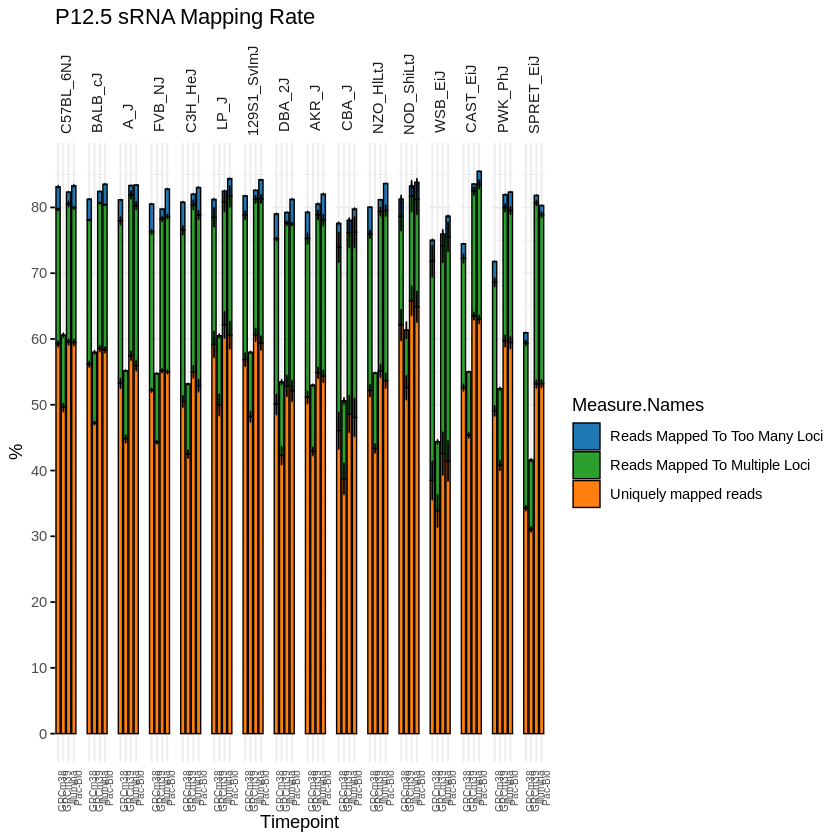

In [17]:
# Your existing code for reading and preprocessing data here...
# Create the stacked bar plot with error bars using ggbarplot
plot <- ggbarplot(filter(data, Timepoint == 'P12.5'),
          x = "genomes", y = "Measure.Values", 
          fill= "Measure.Names",
          add = "mean_se",
          width =0.8,
          add.params = list(color = "#000000"),
          nrow =1,
          size= 0.4,
          facet.by = "Strains",
          error.plot = "errorbar",
          title = "P12.5 sRNA Mapping Rate") + 
   # Apply ggpubr theme for consistency  # Major breaks every 10
  geom_hline(yintercept = seq(0, 75, by = 5), linetype = "dashed", color = "lightgrey", size = 0.0001) + # Add minor grid lines
  geom_hline(yintercept = seq(0, 80, by = 10), linetype = "dashed", color = "lightgrey", size = 0.0001) + 
  labs(x = "Timepoint", y = "%") +  # Customize axis labels
  scale_fill_manual(values = stacked_bar_colors) +  # Set custom fill colors  
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size=6),
        strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0.1),
        axis.ticks.y = element_line(color = "black"),
        panel.ontop = FALSE) +  # Ensure bars are drawn on top of grid lines
  scale_y_continuous(breaks = seq(0, 100, by = 10)) 


plot
# Save the plot as a PDF file
ggsave("sRNA_MApping_P12.5_by_genome_stacked_bar_plot.pdf", plot = plot, device = "pdf", width = 10, height = 4)

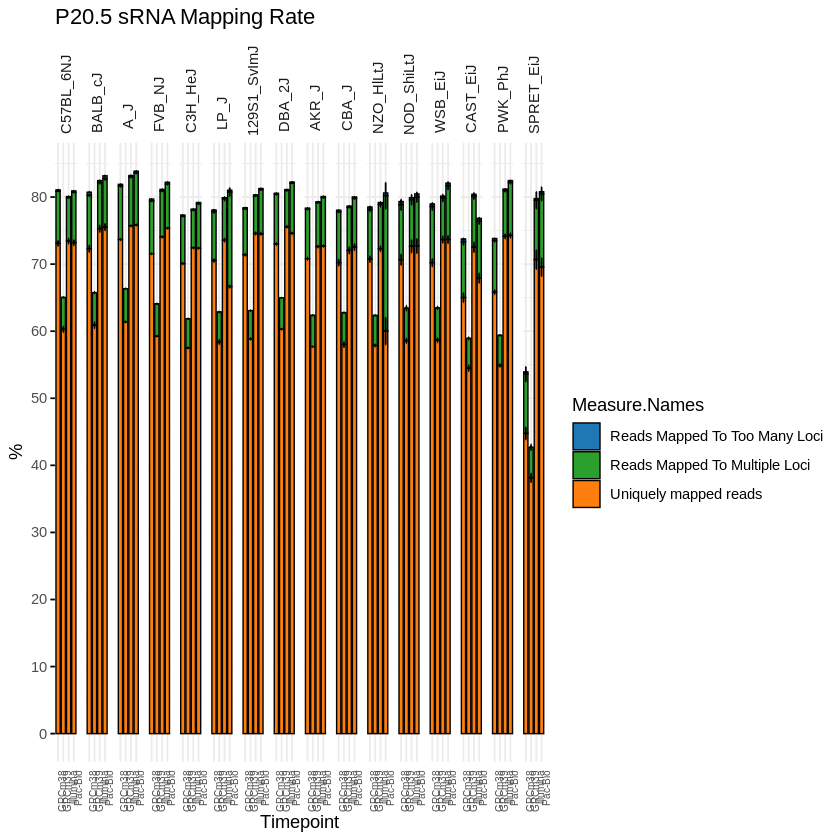

In [18]:
# Your existing code for reading and preprocessing data here...
# Create the stacked bar plot with error bars using ggbarplot
plot <- ggbarplot(filter(data, Timepoint == 'P20.5'),
          x = "genomes", y = "Measure.Values", 
          fill= "Measure.Names",
          add = "mean_se",
          width =0.8,
          add.params = list(color = "#000000"),
          nrow =1,
          size= 0.4,
          facet.by = "Strains",
          error.plot = "errorbar",
          title = "P20.5 sRNA Mapping Rate") + 
   # Apply ggpubr theme for consistency  # Major breaks every 10
  geom_hline(yintercept = seq(0, 75, by = 5), linetype = "dashed", color = "lightgrey", size = 0.0001) + # Add minor grid lines
  geom_hline(yintercept = seq(0, 80, by = 10), linetype = "dashed", color = "lightgrey", size = 0.0001) + 
  labs(x = "Timepoint", y = "%") +  # Customize axis labels
  scale_fill_manual(values = stacked_bar_colors) +  # Set custom fill colors  
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size=6),
        strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0.1),
        axis.ticks.y = element_line(color = "black"),
        panel.ontop = FALSE) +  # Ensure bars are drawn on top of grid lines
  scale_y_continuous(breaks = seq(0, 100, by = 10)) 


plot
# Save the plot as a PDF file
ggsave("sRNA_MApping_P20.5_by_genome_stacked_bar_plot.pdf", plot = plot, device = "pdf", width = 10, height = 4)